In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import pyfar as pf
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
import scienceplots
plt.style.use(['science','no-latex'])

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=2,
    p_ref=2e-5,
    revolutions=100,
    num_obs_times_per_rev=100,
    device='cuda',
)

In [2]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    params=params,
    dtype=torch.float32
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [203]:
r_observer = np.array([[0.1, 1.8, 0]])
propeller.run_aeroacoustics(observer_positions=r_observer,
        lt=0.02,
        i=2e-3,
        alpha_stall=15, 
        keep_bpm_components=True)

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 11.716 ms
[CUDA TIMING] BPM.__init__: 0.579 ms
[CUDA TIMING] get_observer_times: 0.385 ms
[CUDA TIMING] calculate_f1a_pressure: 5.170 ms
[CUDA TIMING] combine_sources (F1A): 1.266 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 1.312 ms
[CUDA TIMING] BPM.run_forward_bpm: 17.332 ms
[CUDA TIMING] combine_sources_bpm: 1.092 ms


In [204]:
t = propeller.t.cpu().numpy()[:, 0]
p_tone = propeller.p_tot.cpu().numpy()[:, 0]

fs = 1 / (t[1] - t[0])
signal = pf.Signal(p_tone, fs, fft_norm='rms')
F1A_frequencies = signal.frequencies
F1A_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.params.p_ref).squeeze()

In [205]:
f_low = propeller.third_octave_freqs / (2 ** (1 / 6))
f_high = propeller.third_octave_freqs * (2 ** (1 / 6))
freqs = propeller.freq[:, 0]
mask = (propeller.freq[:, 0:1].T >= f_low.unsqueeze(1)) & \
       (propeller.freq[:, 0:1].T < f_high.unsqueeze(1))

# 4. Convert SPL to Power
p_raw = 10 ** (propeller.spl / 10)
p_band = torch.matmul(mask.float(), p_raw)
f1a_spl_3oct = 10 * torch.log10(p_band.clamp(min=1e-12))
f1a_spl_3oct[p_band == 0] = float('-inf')

In [206]:
def load_data(filepath):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels']['1']['time']
    p = data['sound']['channels']['1']['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs

# 1. Load data
# t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-21-17_RPM_5000.pkl')
t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-14-55_RPM_7000.pkl')
# t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x5e_2024-11-28-11-23-21_RPM_7000.pkl')
signal = pf.Signal(p_total, fs_total, fft_norm='rms')
meas_frequencies = signal.frequencies
meas_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.params.p_ref).squeeze()

In [207]:
blade_passing_freq = 1 / params.blade_passing_period

In [208]:
exp_spl_3oct = []
for fc in propeller.third_octave_freqs:
    f_low, f_high = fc / (2**(1/6)), fc * (2**(1/6))
    mask = (meas_frequencies >= f_low.cpu().numpy()) & (meas_frequencies < f_high.cpu().numpy())
    if np.any(mask):
        P_band = np.sum(10**(meas_spl[mask] / 10))
        exp_spl_3oct.append(10 * np.log10(P_band))
    else:
        exp_spl_3oct.append(-np.inf)

exp_spl_3oct = np.array(exp_spl_3oct)

In [209]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = lambda f: (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra(f)) - 20 * np.log10(ra(1000))

In [210]:
def calc_oaspl(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs.cpu().numpy()[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl[f >= 0.9*blade_passing_freq] / 10)))

In [211]:
L_total = 10 * torch.log10(
    10 ** (f1a_spl_3oct / 10)
    + 10 ** (propeller.spl_total / 10)
)

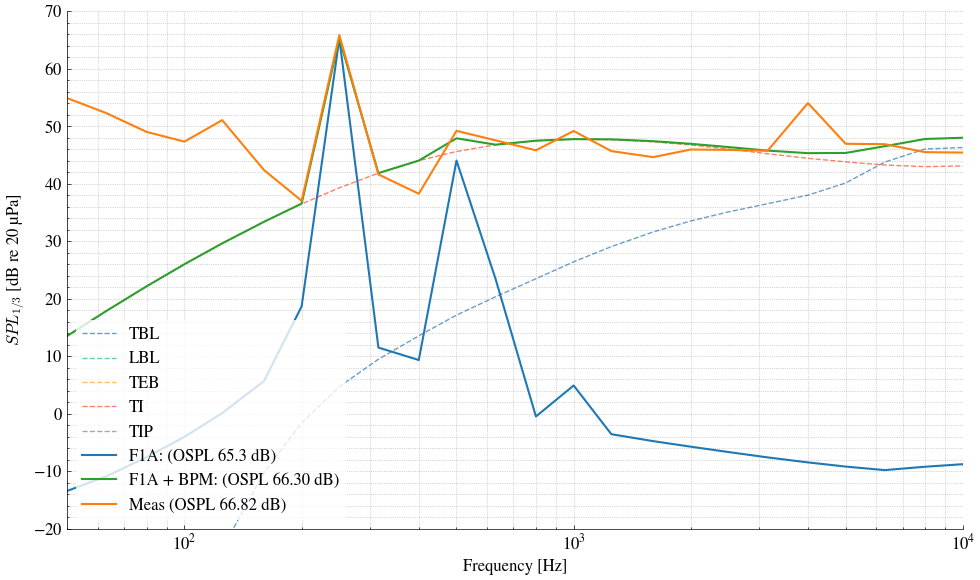

In [212]:
color_5e = 'tab:blue'
color_7e = 'tab:orange'
color_8e = 'tab:green'

# Values for labels
ospl_f1a = calc_oaspl(f1a_spl_3oct.cpu().numpy()[:, 0], propeller.third_octave_freqs, weighted=False)
oaspl_f1a = calc_oaspl(f1a_spl_3oct.cpu().numpy()[:, 0], propeller.third_octave_freqs, weighted=True)

ospl_exp = calc_oaspl(exp_spl_3oct, propeller.third_octave_freqs, weighted=False)
oaspl_exp = calc_oaspl(exp_spl_3oct, propeller.third_octave_freqs, weighted=True)

ospl_tot = calc_oaspl(L_total.cpu().numpy()[:, 0], propeller.third_octave_freqs, weighted=False)
oaspl_tot = calc_oaspl(L_total.cpu().numpy()[:, 0], propeller.third_octave_freqs, weighted=True)

# plt.figure(figsize=(4.5, 3))
plt.figure(figsize=(10, 6))

# Components (keeping these simpler to avoid legend clutter)
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['tbl'][:, 0], '--', alpha=0.6, label='TBL')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['lbl'][:, 0], '--', alpha=0.6, label='LBL')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['teb'][:, 0], '--', alpha=0.6, label='TEB')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['ti'][:, 0], '--', alpha=0.6, label='TI')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['tv'][:, 0], '--', alpha=0.6, label='TIP')

plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), f1a_spl_3oct.cpu().numpy()[:, 0], 
             label=f'F1A: (OSPL {ospl_f1a:.1f} dB)', color=color_5e, linewidth=1.5)
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), L_total.cpu().numpy()[:, 0], '-', 
             label=f'F1A + BPM: (OSPL {ospl_tot:.2f} dB)', color=color_8e, linewidth=1.5)
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), exp_spl_3oct, '-', 
             label=f'Meas (OSPL {ospl_exp:.2f} dB)', color=color_7e, linewidth=1.5)


# max_f = np.max(propeller.freq.cpu().numpy())
# harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
# for bpf in harmonic_freqs:
#     plt.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

plt.xlabel('Frequency [Hz]', fontsize=12)
plt.ylabel('$SPL_{1/3}$ [dB re 20 µPa]', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='both', ls=':')
plt.legend(loc='lower left', fontsize=12, frameon=True, edgecolor='none')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().tick_params(top=False, right=False, which='both')
plt.xlim(50, 10000)
plt.ylim(-20, 70)
plt.tight_layout()
plt.savefig('../Figures/BPM_val.pdf', dpi=200)
plt.show()